In [1]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial
import numpy as np


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = BNCI2014_001()
num=10


In [3]:
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])


Choosing from all possible events


In [4]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from sklearn.preprocessing import FunctionTransformer
from functools import partial

def frequency_mask(X, sfreq=250, fmin=4, fmax=40, band_width_min=4, band_width_max=8):
    X = X.copy()

    band_width = np.random.uniform(band_width_min, band_width_max)
    start_freq = np.random.uniform(fmin, fmax - band_width)
    stop_freq = start_freq + band_width

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=sfreq,
        output="sos"
    )

    X = sosfiltfilt(sos, X, axis=-1)

    return X

In [5]:
pipeline = make_pipeline(
            FunctionTransformer(frequency_mask),
            CSP(n_components=8),
            LDA()
        )

In [6]:
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [7]:
results = evaluation.process({"csp+lda": pipeline})

Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 51 (2.2e-16 eps * 22 dim * 1e+16  ma

         Accuracy  Balanced Accuracy  score_f1_macro
session                                             
0train   0.578100           0.578809        0.555063
1test    0.542798           0.542751        0.497882


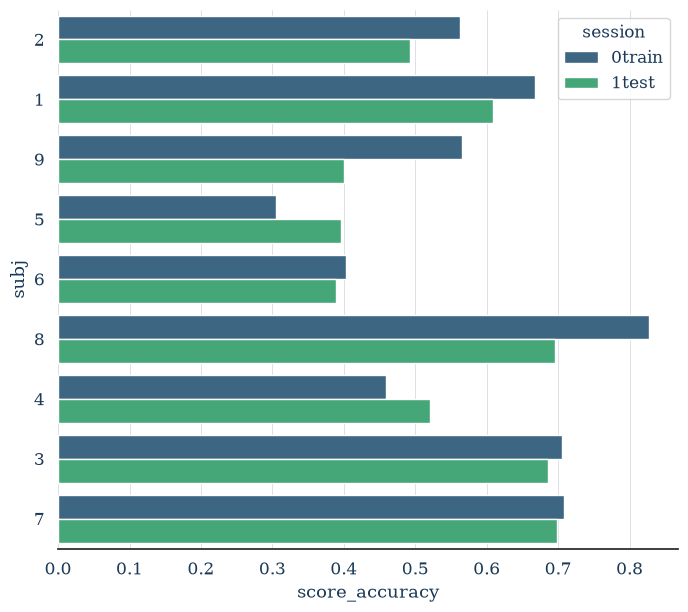

In [8]:
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

print(avgRes)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

In [5]:

def frequency_mask(X, start_freq, band_width, sfreq=250):
    X = X.copy()

    stop_freq = start_freq + band_width

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=sfreq,
        output="sos"
    )

    X = sosfiltfilt(sos, X, axis=-1)

    return X

In [6]:
bandwidths=[4,6,8]

fmin=4
fmax=40
nums=3

In [7]:
accuracy=[]
freqs=[0,0,0]
for bw in bandwidths:
    all_avgs = []

    for i in range(nums):
        freqs[i]=np.random.uniform(fmin, fmax - bw)
    
    print(freqs)
    
    for freq in freqs:
            
        hider = FunctionTransformer(
            partial(
                frequency_mask,
                start_freq=freq,
                band_width=bw
            )
        )

        pipeline = make_pipeline(
            hider,
            CSP(n_components=8),
            LDA()
        )

        

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


[33.9897114545553, 6.762159752068175, 35.614806917423024]
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 22 dim * 7.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.9e+

Choosing from all possible events


...

[6.200010247704619, 13.095764061934243, 31.85378770376194]
Computing rank from data with rank=None
    Using tolerance 34 (2.2e-16 eps * 22 dim * 6.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 34 (2.2e-16 eps * 22 dim * 7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 37 (2.2e-16 eps * 22 dim * 7.6e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 37 (2.2e-16 eps * 22 dim * 7.6e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 37 (2.2e-16 eps * 22 dim * 7.7e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.8e+

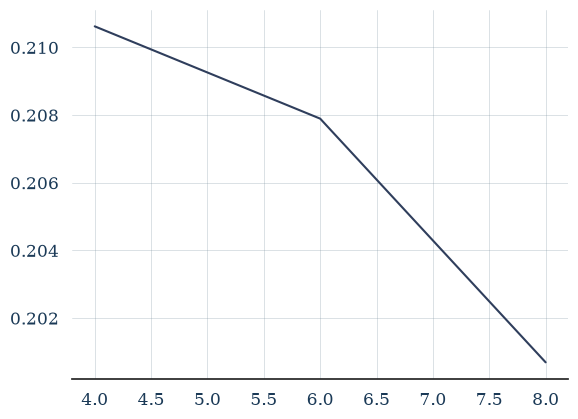

In [8]:
plt.plot(bandwidths, accuracy)

In [9]:
sum(accuracy)/len(accuracy)

np.float32(0.2064054)